In [1]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt


In [2]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Tdata.csv')

Training with kernel=linear, C=0.1, gamma=scale
MSE (normalized): 0.007014629818826911
Training with kernel=linear, C=0.1, gamma=auto
MSE (normalized): 0.007014629818826911
Training with kernel=linear, C=1, gamma=scale
MSE (normalized): 0.005632253323588096
Training with kernel=linear, C=1, gamma=auto
MSE (normalized): 0.005632253323588096
Training with kernel=linear, C=10, gamma=scale
MSE (normalized): 0.005565494518045634
Training with kernel=linear, C=10, gamma=auto
MSE (normalized): 0.005565494518045634
Training with kernel=rbf, C=0.1, gamma=scale
MSE (normalized): 0.009402962084865782
Training with kernel=rbf, C=0.1, gamma=auto
MSE (normalized): 0.011126600625618318
Training with kernel=rbf, C=1, gamma=scale
MSE (normalized): 0.008869347452998402
Training with kernel=rbf, C=1, gamma=auto
MSE (normalized): 0.0067182374601026315
Training with kernel=rbf, C=10, gamma=scale
MSE (normalized): 0.012707958067213561
Training with kernel=rbf, C=10, gamma=auto
MSE (normalized): 0.0055745958

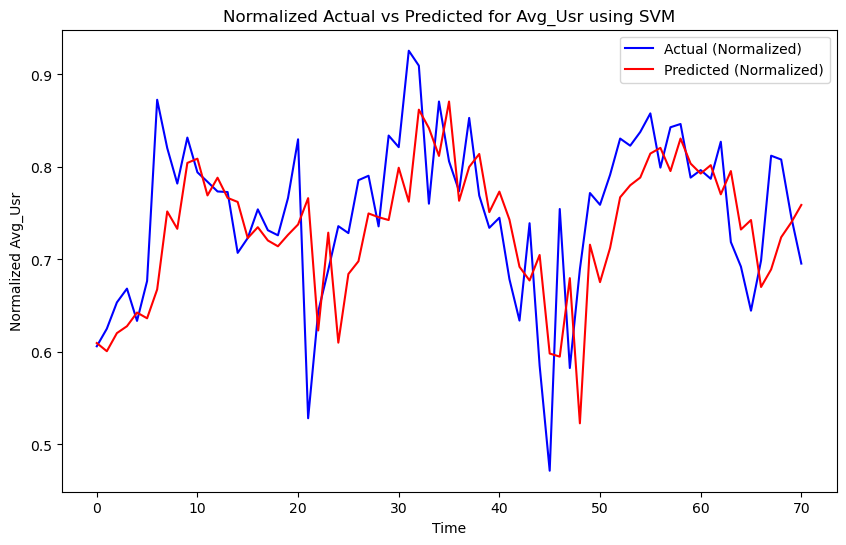

In [3]:


# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to a 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'Avg_Usr'
feature = 'Avg_Usr'

# Normalize the 'Avg_Usr' data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for SVM (look_back=3)
look_back = 3
X_train, y_train = create_dataset_svm(train, look_back=look_back)
X_test, y_test = create_dataset_svm(test, look_back=look_back)

# Train SVM model with different hyperparameters
best_mse = float('inf')
best_params = {}
best_model = None

# Hyperparameter tuning loop for SVM
for kernel in ['linear', 'rbf', 'poly']:
    for C in [0.1, 1, 10]:
        for gamma in ['scale', 'auto']:
            print(f'Training with kernel={kernel}, C={C}, gamma={gamma}')
            svm_model = SVR(kernel=kernel, C=C, gamma=gamma)
            svm_model.fit(X_train, y_train)
            
            # Predict and calculate MSE
            test_predict = svm_model.predict(X_test)
            mse = mean_squared_error(y_test, test_predict)
            print(f'MSE (normalized): {mse}')
            
            # Track the best model
            if mse < best_mse:
                best_mse = mse
                best_params = {'kernel': kernel, 'C': C, 'gamma': gamma}
                best_model = svm_model

print(f'Best MSE (normalized): {best_mse} with params: {best_params}')

# Predict with the best model
best_test_predict = best_model.predict(X_test)

# Plot the best model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(best_test_predict, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using SVM')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

In [5]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
import matplotlib.pyplot as plt

Epoch 1/50
9/9 [==============================] - 7s 179ms/step - loss: 0.0591 - val_loss: 0.0353
Epoch 2/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0217 - val_loss: 0.0062
Epoch 3/50
9/9 [==============================] - 0s 13ms/step - loss: 0.0138 - val_loss: 0.0044
Epoch 4/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0062 - val_loss: 0.0061
Epoch 5/50
9/9 [==============================] - 0s 13ms/step - loss: 0.0045 - val_loss: 0.0017
Epoch 6/50
9/9 [==============================] - 0s 13ms/step - loss: 0.0040 - val_loss: 0.0013
Epoch 7/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0029 - val_loss: 0.0019
Epoch 8/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0028 - val_loss: 0.0012
Epoch 9/50
9/9 [==============================] - 0s 13ms/step - loss: 0.0025 - val_loss: 0.0018
Epoch 10/50
9/9 [==============================] - 0s 13ms/step - loss: 0.0030 - val_loss: 0.0013
Epoch 11/50
9/9 [===========

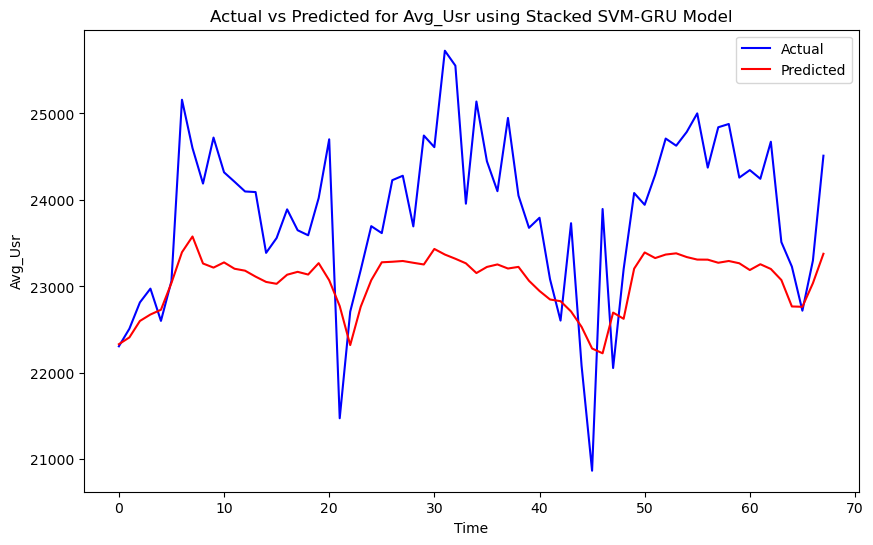

Hybrid Model MSE: 1126111.0417626072


In [6]:

# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Tdata.csv')

# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'Avg_Usr'
feature = 'Avg_Usr'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for SVM (look_back=3)
look_back = 3
X_train_svm, y_train_svm = create_dataset_svm(train, look_back=look_back)
X_test_svm, y_test_svm = create_dataset_svm(test, look_back=look_back)

# Train SVM model (best hyperparameters from tuning)
svm_model = SVR(kernel='rbf', C=1, gamma='scale')
svm_model.fit(X_train_svm, y_train_svm)

# Predict with SVM model
train_predict_svm = svm_model.predict(X_train_svm)
test_predict_svm = svm_model.predict(X_test_svm)

# Prepare the data for GRU model
def create_dataset_gru(svm_predictions, original_data, look_back=1):
    X, Y = [], []
    for i in range(len(svm_predictions) - look_back):
        # Combine original time series data and SVM predictions as features
        feature_set = np.hstack((original_data[i:(i + look_back)], svm_predictions[i:(i + look_back)].reshape(-1, 1)))
        X.append(feature_set)
        Y.append(original_data[i + look_back, 0])
    return np.array(X), np.array(Y)

# Creating datasets for GRU
X_train_gru, y_train_gru = create_dataset_gru(train_predict_svm, train, look_back=look_back)
X_test_gru, y_test_gru = create_dataset_gru(test_predict_svm, test, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train_gru = np.reshape(X_train_gru, (X_train_gru.shape[0], X_train_gru.shape[1], 2))  # Two features: original and SVM
X_test_gru = np.reshape(X_test_gru, (X_test_gru.shape[0], X_test_gru.shape[1], 2))

# Define and train the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression

    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train GRU model
gru_model = build_gru_model((look_back, 2))
gru_model.fit(X_train_gru, y_train_gru, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the GRU model
train_predict_gru = gru_model.predict(X_train_gru)
test_predict_gru = gru_model.predict(X_test_gru)

# Invert predictions and actual values back to original scale
train_predict_gru = scaler.inverse_transform(train_predict_gru)
test_predict_gru = scaler.inverse_transform(test_predict_gru)
y_train_gru = scaler.inverse_transform([y_train_gru])
y_test_gru = scaler.inverse_transform([y_test_gru])

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(y_test_gru[0], label='Actual', color='blue')
plt.plot(test_predict_gru, label='Predicted', color='red')
plt.title('Actual vs Predicted for Avg_Usr using Stacked SVM-GRU Model')
plt.xlabel('Time')
plt.ylabel('Avg_Usr')
plt.legend()
plt.show()

# Calculate MSE for the hybrid model
mse_gru = mean_squared_error(y_test_gru[0], test_predict_gru)
print(f'Hybrid Model MSE: {mse_gru}')